# EM Debt Carry — a quantitative teardown 🔬
### Promised-vs-collected decomposition on a dual TR/price-only tape · NW-HAC spread and equity-beta regression · worst-decile Welch split · a five-window crisis ledger · the EMLC local-currency contrast · lag/subperiod robustness · synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survives_the_crises%3F: Mixed](https://img.shields.io/badge/Survives_the_crises%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The EMBI spread is one of the most-quoted numbers in fixed income; the question is whether the *collected* total-return spread on the investable package clears the desk's bar — and what it is made of when it doesn't.

> ⚠️ **Data note.** yfinance daily closes, twice (auto-adjusted TR and price-only), for EMB / EMLC / IEF / SPY / BIL; headline window 2008-01 → 2026-06 (222 months, GFC included), EMLC contrast 2010-08 →. Index funds — the defaults are *on* the tape (survivorship named and dismissed on the Signal axis; the index rulebook's liquidity screens are the remaining shaping). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `1bff8a946cdf`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from em_debt_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TR, PX = data.load_real()
    MTR, MPX = st.aligned_monthly(TR, PX, ["EMB", "IEF", "SPY", "BIL"])
else:
    TR = PX = MTR = MPX = None
print("real EM-debt cache present:", HAVE_REAL,
      "| months:", (0 if MTR is None else len(MTR)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-01-31', 'end': '2026-06-30', 'n_months': 222, 'years': 18.5, 'coupon_emb': 4.97, 'coupon_emb_t': 35.2, 'coupon_ief': 2.46, 'pickup_bps': 20.24, 'pickup_ann': 2.46, 'pickup_t': 20.09, 'roll_min': 1.3, 'roll_med': 2.48, 'roll_max': 3.42, 'spread_bps': 17.83, 'spread_ann': 2.16, 'spread_t': 0.99, 'skew': -1.72, 'wealth_emb': 232.8, 'wealth_ief': 170.2, 'perf': [('EMB', 4.67, 11.44, 0.35, -26.74), ('IEF', 2.92, 6.71, 0.27, -23.15), ('SPY', 11.24, 15.72, 0.68, -46.32), ('BIL', 1.27, 0.54, None, -0.42)], 'off_bps': -438.0, 'rest_bps': 70.5, 'gap_bps': -508.5, 'gap_welch': -4.84, 'corr_spy': 0.69, 'n_off': 23, 'n_rest': 199, 'cut_pct': -5.3, 'alpha_bps': -19.35, 'alpha_ann': -2.3, 'alpha_t': -1.44, 'b_ief': 0.77, 'b_ief_t': 4.71, 'b_spy': 0.46, 'b_spy_t': 7.85, 'r2': 0.57, 'emlc_n': 191, 'emlc_start': '2010-08-31', 'emlc_coupon': 5.6, 'emlc_pickup': 3.29, 'emlc_pickup_t': 21.55, 'emlc_spread_bps': -5.16, 'emlc_spread_ann': -0.62, 'emlc_spread_t': -0.24, 'emlc_wealth': 118.2, 'ief_wealth_lc': 139.8, 'emb_lc_spread_ann': 2.17, 'emb_lc_spread_t': 1.24, 'fx_bill_bps': 23.09, 'fx_bill_ann': 2.81, 'fx_bill_t': 1.81, 'ledger': [('GFC 2008', -17.33, 7), ('Taper tantrum 2013', -2.91, 5), ('EM stress 2018', -5.29, 8), ('COVID 2020', -18.79, 3), ('Rate/Russia 2022', -9.83, 10)], 'n_crisis': 33, 'n_calm': 189, 'crisis_bps': -164.1, 'calm_bps': 49.6, 'calm_t': 3.38, 'crisis_cum': -54.1, 'calm_cum': 93.7, 'total_cum': 39.6, 'ledger_welch': -2.15, 'handback': 58, 'crisis_dd': [('GFC 2008', -34.1, None, -6.0, -46.0), ('Taper 2013', -14.5, -15.5, -9.1, -5.6), ('EM 2018', -6.4, -16.6, -2.7, -9.9), ('COVID 2020', -26.5, -20.6, -4.7, -33.7), ('2022', -26.0, -20.1, -17.4, -24.5)], 'robust': [('NW lags=3', 17.83, 0.96), ('NW lags=6', 17.83, 0.99), ('NW lags=12', 17.83, 1.1), ('ex-GFC 2010+', 16.46, 1.17), ('2016-07+', 23.46, 1.23)], 'syn': [(0.0, 0.0, 4.54, 0.61, 26.1, 1.21), (30.0, 0.45, 62.91, 3.85, -376.4, -14.41)], 'fingerprint': '1bff8a946cdf'}


real EM-debt cache present: True | months: 222


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Real on the coupon, none on the collected spread*: promised pickup **+2.46%/yr** at HAC **t = +20.1** vs collected TR spread **+2.16%/yr** at HAC **t = +0.99** (n = 222, skew -1.72). |
| **Tradability** | `MIRAGE` | b_SPY = **+0.46** (t = +7.85), R² = 0.57; NW-HAC alpha vs IEF+SPY = **-2.30%/yr** (t = -1.44); worst-decile-SPY spread -438 bps/mo (Welch t = -4.84); EMLC lost to IEF outright (-0.62%/yr). |
| **Survives the crises?** | `MIXED` | All five windows negative; crisis months -164 bps/mo vs calm +49.6 (Welch t = -2.15); cumulative -54.1% in-crisis vs +93.7% out; whole-sample t collapses from +3.38 to +0.99. |

> 💡 In plain words: the coupon is a certainty; keeping it is a coin-flip that always lands tails in a crisis.

## 1 · The claim, steelmanned

Let $r^{TR}_{t}$ and $r^{PX}_{t}$ be a fund's monthly total-return and price-only returns; its **coupon component** is $c_t = r^{TR}_t - r^{PX}_t$. With EMB and the duration-matched IEF (both ~7y effective duration, both USD):

$$\text{promised}_t = c^{EMB}_t - c^{IEF}_t, \qquad \text{collected}_t = r^{TR,EMB}_t - r^{TR,IEF}_t.$$

- **H₁ (the carry is collected).** $\overline{\text{collected}} > 0$ with HAC *t* ≥ 2 — the desk bar.
- **H₂ (it is a premium, not a beta).** The NW-HAC intercept of EMB's excess return on IEF + SPY excess returns is positive — something is left after duration and equity risk.
- **H₃ (it survives its crises).** The spread's cumulative take inside the named risk-off windows does not destroy the calm-month harvest.

We find **H₁ rejected** (t = 0.99), **H₂ rejected with the sign flipped** (alpha −2.30%/yr, t = −1.44, b_SPY = +0.46 at t = +7.85), **H₃ split** (arithmetic yes, +39.6% cumulative; statistical no, the five windows claw back 58% and the t with it).

## 2 · So what? — what rides on each answer

The EMBI spread (300-450 bp historically) is the most-quoted carry number in EM investing, and the literature genuinely splits: Klingen-Weder-Zettelmeyer (2004) find a century of EM lending returned roughly Treasuries after defaults; Meyer-Reinhart-Trebesch (2022) find +3-4%/yr *including* defaults. Both can be right about their samples — the question for an allocator is what the **investable, post-2007 package** did. Borri-Verdelhan (2011) supply the null we test against: EM sovereign returns are compensation for *systematic* (equity-like) risk, taken at the worst times. If they're right, the spread should (a) fail unconditional significance despite a positive mean, (b) load on SPY with no residual alpha, and (c) concentrate its losses in equity crash months. All three predictions hit.

## 3 · How we'd know — the protocol

- **Tape.** Dual yfinance closes (TR + price-only), EMB/EMLC/IEF/SPY/BIL; headline window 2008-01-31 → 2026-06-30 (222 months); as-of frozen, partial month dropped; fingerprint `1bff8a946cdf`.
- **Duration match.** EMB ≈ 7y effective duration vs IEF 7-8y — the TR spread isolates credit/carry, not a rates bet.
- **Inference.** NW-HAC *t* (6 lags; 3/12 as robustness) on every monthly mean — bond spreads are serially correlated. Welch *t* on the risk-off group split. Excess-vs-excess Sharpe (over BIL).
- **Execution.** Passive buy-and-hold decomposition; entry at the first month-end close of the common window (one documented, trivial lag — no timing signal exists to lag). Expense ratios (0.39%/0.30%) are inside the tape; two one-way trades over 18.5y ≈ 0.5 bps/yr amortised.
- **Crisis windows.** Five fixed calendar windows (2008, 2013, 2018, 2020, 2022) documented from the events, not fitted to the series.
- **Positive control.** A deterministic synthetic world with planted spread / coupon / risk-off-beta knobs: the null must stay silent, the plants must light up.

## 4 · The teardown

### 4a · Promised vs collected — two t-stats, one tape

The coupon pickup (TR-minus-price-only, EMB minus IEF) against the collected TR spread, each with its HAC *t*. Same 222 months, same funds — and a factor-20 gap in evidence.

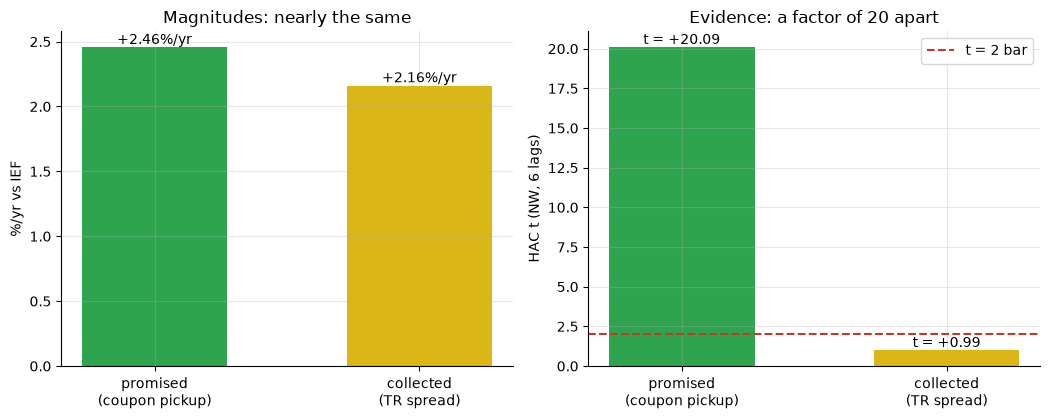

promised +2.46%/yr (t +20.09)   collected +2.16%/yr (t +0.99)


In [2]:
if HAVE_REAL:
    yp = st.yield_pickup(MTR, MPX, 'EMB', 'IEF')
    ss = st.spread_stats(MTR, 'EMB', 'IEF')
    vals = [(yp['pickup_ann_pct'], yp['hac_t']), (ss['spread_ann_pct'], ss['hac_t'])]
else:
    vals = [(R['pickup_ann'], R['pickup_t']), (R['spread_ann'], R['spread_t'])]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
labs = ['promised\n(coupon pickup)', 'collected\n(TR spread)']
a1.bar(labs, [v[0] for v in vals], color=[GREEN, AMBER], width=.55)
for i, v in enumerate(vals): a1.annotate(f'{v[0]:+.2f}%/yr', (i, v[0]), ha='center', va='bottom')
a1.set_ylabel('%/yr vs IEF'); a1.set_title('Magnitudes: nearly the same')
a2.bar(labs, [v[1] for v in vals], color=[GREEN, AMBER], width=.55)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, v in enumerate(vals): a2.annotate(f't = {v[1]:+.2f}', (i, v[1]), ha='center', va='bottom')
a2.set_ylabel('HAC t (NW, 6 lags)'); a2.set_title('Evidence: a factor of 20 apart'); a2.legend()
plt.tight_layout(); plt.show()
print(f'promised {vals[0][0]:+.2f}%/yr (t {vals[0][1]:+.2f})   collected {vals[1][0]:+.2f}%/yr (t {vals[1][1]:+.2f})')

> 💡 In plain words: the *promise* (+2.46%/yr, t = +20.1, positive in every rolling year between +1.3% and +3.4%) is one of the most certain numbers on the desk. The *payoff* (+2.16%/yr, t = +0.99, skew -1.72) doesn't clear half the bar. A yield is not a return.


### 4b · What the collected spread is made of — the beta regression

NW-HAC regression of EMB's excess return (over BIL) on IEF and SPY excess returns. If the carry is a genuine premium, the intercept is positive; if it is packaging, the betas absorb everything.

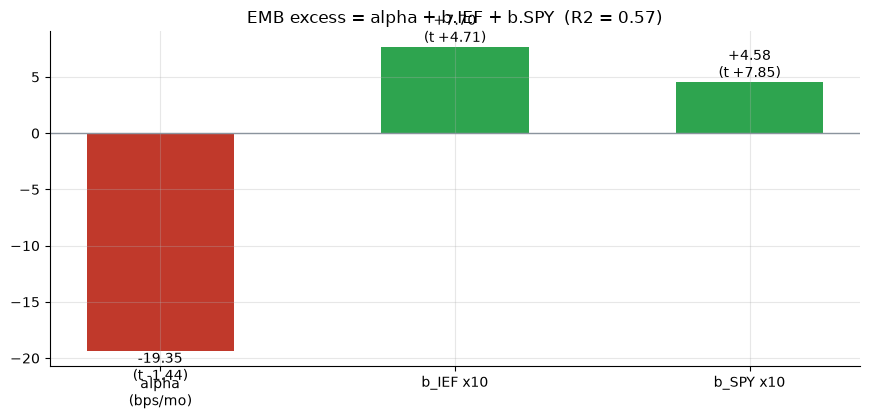

alpha -19.35 bps/mo (-2.30%/yr) t=-1.44 | b_IEF +0.77 (t +4.71) b_SPY +0.46 (t +7.85)


In [3]:
if HAVE_REAL:
    cp = st.carry_premium(MTR, 'EMB')
else:
    cp = dict(alpha_bps_mo=R['alpha_bps'], alpha_ann_pct=R['alpha_ann'], t_alpha=R['alpha_t'],
              beta_IEF=R['b_ief'], t_IEF=R['b_ief_t'], beta_SPY=R['b_spy'], t_SPY=R['b_spy_t'], r2=R['r2'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
names = ['alpha\n(bps/mo)', 'b_IEF x10', 'b_SPY x10']
vals = [cp['alpha_bps_mo'], cp['beta_IEF'] * 10, cp['beta_SPY'] * 10]
ts = [cp['t_alpha'], cp['t_IEF'], cp['t_SPY']]
cols = [RED if v < 0 else GREEN for v in vals]
ax.bar(names, vals, color=cols, width=.5)
for i, (v, t) in enumerate(zip(vals, ts)):
    ax.annotate(f'{v:+.2f}\n(t {t:+.2f})', (i, v), ha='center', va='bottom' if v >= 0 else 'top')
ax.axhline(0, color=GREY, lw=1)
ax.set_title(f"EMB excess = alpha + b.IEF + b.SPY  (R2 = {cp['r2']:.2f})")
plt.tight_layout(); plt.show()
print(f"alpha {cp['alpha_bps_mo']:+.2f} bps/mo ({cp['alpha_ann_pct']:+.2f}%/yr) t={cp['t_alpha']:+.2f} | "
      f"b_IEF {cp['beta_IEF']:+.2f} (t {cp['t_IEF']:+.2f}) b_SPY {cp['beta_SPY']:+.2f} (t {cp['t_SPY']:+.2f})")

> 💡 In plain words: EMB ≈ **0.77 × Treasuries + 0.46 × stock market − 2.3%/yr**. More than half the variance (R² = 0.57) is duration plus equity beta; the stock loading is unambiguous (t = +7.85); and the residual "carry premium" is *negative* though not significantly so. A DIY IEF+SPY blend replicated the package with nothing left over — that is the Mirage stamp, in one regression.


### 4c · The carry-crash profile — the Welch split and the skew

Monthly spread conditional on SPY's worst decile vs the rest, plus the histogram that shows where the information lives.

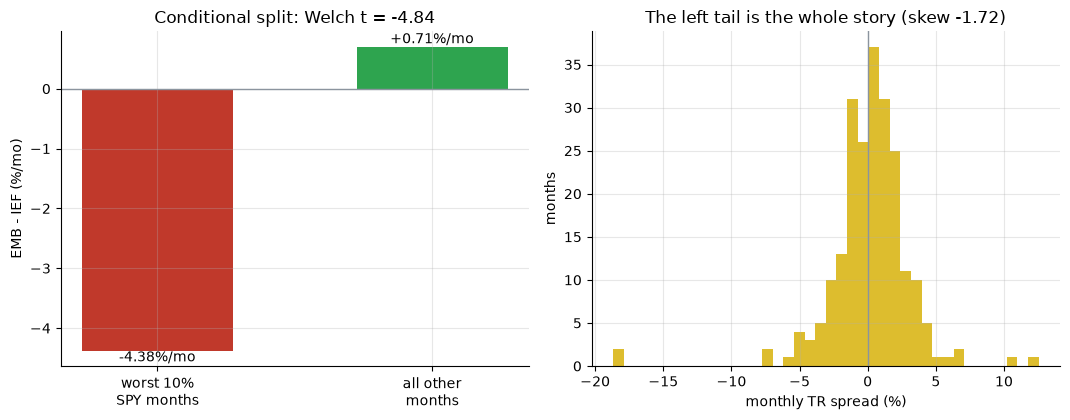

off -438.0 bps/mo vs rest +70.5 | gap -508.5 (Welch t -4.84) | corr(spread, SPY) +0.69


In [4]:
if HAVE_REAL:
    ro = st.riskoff_profile(MTR, 'EMB', 'IEF')
    sp = (MTR['EMB'] - MTR['IEF']) * 100
else:
    ro = dict(off_bps_mo=R['off_bps'], rest_bps_mo=R['rest_bps'], gap_bps_mo=R['gap_bps'],
              welch_t=R['gap_welch'], corr_spy=R['corr_spy'], n_off=R['n_off'], n_rest=R['n_rest'])
    rng = np.random.default_rng(612); sp = pd.Series(rng.normal(0.18, 2.2, 222))  # illustrative only
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(['worst 10%\nSPY months', 'all other\nmonths'],
       [ro['off_bps_mo'] / 100, ro['rest_bps_mo'] / 100], color=[RED, GREEN], width=.55)
for i, v in enumerate([ro['off_bps_mo'] / 100, ro['rest_bps_mo'] / 100]):
    a1.annotate(f'{v:+.2f}%/mo', (i, v), ha='center', va='top' if v < 0 else 'bottom')
a1.axhline(0, color=GREY, lw=1); a1.set_ylabel('EMB - IEF (%/mo)')
a1.set_title(f"Conditional split: Welch t = {ro['welch_t']:+.2f}")
a2.hist(sp.dropna(), bins=40, color=AMBER, alpha=.9)
a2.axvline(0, color=GREY, lw=1)
a2.set_xlabel('monthly TR spread (%)'); a2.set_ylabel('months')
a2.set_title('The left tail is the whole story (skew ' + f"{R['skew']:.2f}" + ')')
plt.tight_layout(); plt.show()
print(f"off {ro['off_bps_mo']:+.1f} bps/mo vs rest {ro['rest_bps_mo']:+.1f} | gap {ro['gap_bps_mo']:+.1f} "
      f"(Welch t {ro['welch_t']:+.2f}) | corr(spread, SPY) {ro['corr_spy']:+.2f}")

> 💡 In plain words: 23 months — the stock market's worst decile — cost the spread **-4.4% per month** while the other 199 paid +0.7%. The gap is -508 bps/mo at Welch t = -4.84, and the spread-SPY correlation is +0.69. This is the Brunnermeier-Nagel-Pedersen carry-crash signature on a bond fund: up the stairs, down the elevator, and the elevator is wired to your equity allocation.


### 4d · The third axis — the five-crisis ledger

Cumulative monthly spread inside each fixed risk-off window, and the crisis-vs-calm ledger that decides whether the spread survives the events it insures.

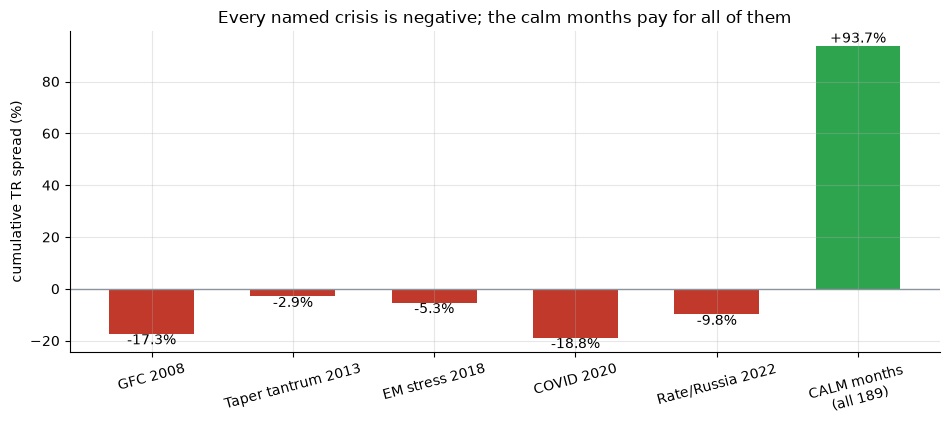

crisis cum -54.1% (33 mo, -164.1 bps/mo)  calm cum +93.7% (189 mo, +49.6 bps/mo, HAC t +3.38)
total +39.6%  | crisis-vs-calm Welch t = -2.15


In [5]:
if HAVE_REAL:
    cl = st.crisis_ledger(MTR, 'EMB', 'IEF')
    per = cl['per_window']
else:
    cl = dict(crisis_cum_pct=R['crisis_cum'], calm_cum_pct=R['calm_cum'], total_cum_pct=R['total_cum'],
              crisis_bps_mo=R['crisis_bps'], calm_bps_mo=R['calm_bps'], welch_t=R['ledger_welch'],
              calm_hac_t=R['calm_t'], n_crisis=R['n_crisis'], n_calm=R['n_calm'])
    per = R['ledger']
fig, ax = plt.subplots(figsize=(9.6, 4.4))
labs = [p[0] for p in per] + ['CALM months\n(all 189)']
vals = [p[1] for p in per] + [cl['calm_cum_pct']]
cols = [RED] * len(per) + [GREEN]
ax.bar(labs, vals, color=cols, width=.6)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, color=GREY, lw=1)
ax.set_ylabel('cumulative TR spread (%)')
ax.set_title('Every named crisis is negative; the calm months pay for all of them')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print(f"crisis cum {cl['crisis_cum_pct']:+.1f}% ({cl['n_crisis']} mo, {cl['crisis_bps_mo']:+.1f} bps/mo)  "
      f"calm cum {cl['calm_cum_pct']:+.1f}% ({cl['n_calm']} mo, {cl['calm_bps_mo']:+.1f} bps/mo, HAC t {cl['calm_hac_t']:+.2f})")
print(f"total {cl['total_cum_pct']:+.1f}%  | crisis-vs-calm Welch t = {cl['welch_t']:+.2f}")

> 💡 In plain words: all five windows are negative — 33 crisis months surrender **-54.1%** of the **+93.7%** the 189 calm months collected (58% handed back), leaving **+39.6%** overall. Calm-only the spread is decisively real (HAC t = +3.38); all-in it is t = +0.99. The spread survives **arithmetically, not statistically** — hence the grey MIXED, spelled out.


### 4e · The local-currency contrast + robustness

EMLC (same sovereigns, local currency, fatter coupon) vs IEF on the common 2010-08+ window; then the HAC-lag and subperiod sweep on the headline spread.

EMLC coupon +5.60%/yr (pickup t +21.6) — but TR spread -0.62%/yr (t -0.24)


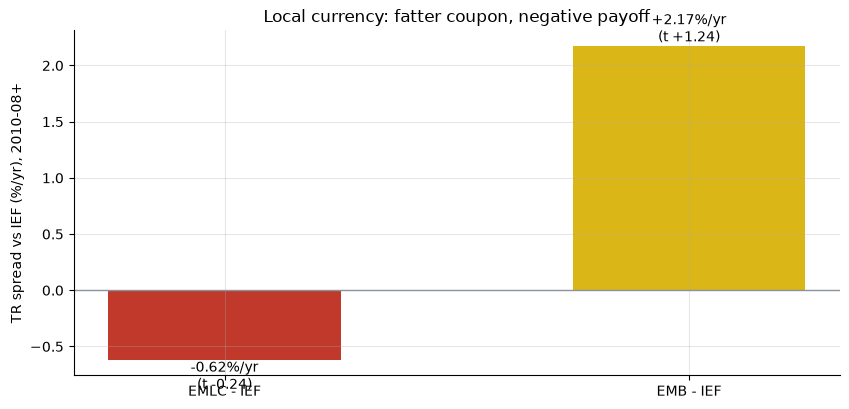

NW lags= 3: +17.83 bps/mo  t = +0.96
NW lags= 6: +17.83 bps/mo  t = +0.99
NW lags=12: +17.83 bps/mo  t = +1.10
ex-GFC 2010+  : +16.46 bps/mo  t = +1.17
2016-07+      : +23.46 bps/mo  t = +1.23


In [6]:
if HAVE_REAL:
    MTR2, MPX2 = st.aligned_monthly(TR, PX, ['EMLC', 'EMB', 'IEF', 'SPY', 'BIL'])
    s_lc = st.spread_stats(MTR2, 'EMLC', 'IEF'); s_hc = st.spread_stats(MTR2, 'EMB', 'IEF')
    y_lc = st.yield_pickup(MTR2, MPX2, 'EMLC', 'IEF')
    rows = [('EMLC - IEF', s_lc['spread_ann_pct'], s_lc['hac_t']),
            ('EMB - IEF', s_hc['spread_ann_pct'], s_hc['hac_t'])]
    print(f"EMLC coupon {y_lc['coupon_name_ann_pct']:+.2f}%/yr (pickup t {y_lc['hac_t']:+.1f}) — "
          f"but TR spread {s_lc['spread_ann_pct']:+.2f}%/yr (t {s_lc['hac_t']:+.2f})")
else:
    rows = [('EMLC - IEF', R['emlc_spread_ann'], R['emlc_spread_t']),
            ('EMB - IEF', R['emb_lc_spread_ann'], R['emb_lc_spread_t'])]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar([r[0] for r in rows], [r[1] for r in rows],
       color=[RED if r[1] < 0 else AMBER for r in rows], width=.5)
for i, r in enumerate(rows):
    ax.annotate(f'{r[1]:+.2f}%/yr\n(t {r[2]:+.2f})', (i, r[1]), ha='center',
                va='top' if r[1] < 0 else 'bottom')
ax.axhline(0, color=GREY, lw=1)
ax.set_ylabel('TR spread vs IEF (%/yr), 2010-08+')
ax.set_title('Local currency: fatter coupon, negative payoff')
plt.tight_layout(); plt.show()
if HAVE_REAL:
    spq = MTR['EMB'] - MTR['IEF']
    for lags in (3, 6, 12):
        mu, t = st.nw_tstat(spq, lags=lags)
        print(f'NW lags={lags:>2}: {mu*1e4:+.2f} bps/mo  t = {t:+.2f}')
    for lab, lo in [('ex-GFC 2010+', '2010-01-01'), ('2016-07+', '2016-07-01')]:
        mu, t = st.nw_tstat(spq.loc[lo:])
        print(f'{lab:<14}: {mu*1e4:+.2f} bps/mo  t = {t:+.2f}')
else:
    for lab, mu, t in R['robust']: print(f'{lab:<14}: {mu:+.2f} bps/mo  t = {t:+.2f}')

> 💡 In plain words: EMLC's coupon is even fatter (+5.6%/yr, pickup t ≈ 22) and its payoff is **negative** (-0.62%/yr; $100 → $118 vs $140 for IEF) — the FX leg bills ~2.8%/yr (EMB−EMLC, t = +1.81); see [364-fx-carry-trade](../../364-fx-carry-trade/README.md) for why. And no HAC lag (t = 0.96-1.10) or subperiod (ex-GFC t = 1.17, last decade t = 1.23) rescues the hard-currency spread either. Du-Schreger (2016) is the formal account of the local-currency wedge.


### 4f · Faithful-engine & power control — we know the truth here

A deterministic synthetic world with planted knobs: `spread` (the TR spread), `coupon` (the pickup, planted at 25 bps/mo) and `beta_spy` (the crash coupling). The null must stay silent; the plants must light up.

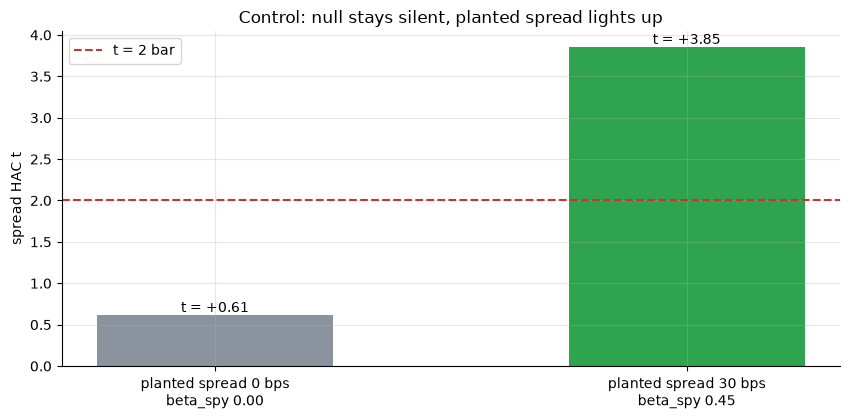

planted  +0.0 bps/mo, b_spy 0.00: spread +4.54 (t +0.61) | pickup +23.72 (t +42.4, planted 25) | risk-off gap +26.1 (Welch +1.21)
planted +30.0 bps/mo, b_spy 0.45: spread +62.91 (t +3.85) | pickup +23.72 (t +42.4, planted 25) | risk-off gap -376.4 (Welch -14.41)


In [7]:
res = []
for spread, beta_spy in [(0.0, 0.0), (0.0030, 0.45)]:
    ttr, tpx = data.synthetic_world(spread=spread, beta_spy=beta_spy, seed=612)
    smtr, smpx = st.aligned_monthly(ttr, tpx, ['EMD', 'IEF', 'SPY', 'BIL'])
    sss = st.spread_stats(smtr, 'EMD', 'IEF')
    syp = st.yield_pickup(smtr, smpx, 'EMD', 'IEF')
    sro = st.riskoff_profile(smtr, 'EMD', 'IEF')
    res.append((spread * 1e4, beta_spy, sss['spread_bps_mo'], sss['hac_t'],
                syp['pickup_bps_mo'], syp['hac_t'], sro['gap_bps_mo'], sro['welch_t']))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labs = [f'planted spread {r[0]:.0f} bps\nbeta_spy {r[1]:.2f}' for r in res]
ax.bar(labs, [r[3] for r in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res): ax.annotate(f't = {r[3]:+.2f}', (i, r[3]), ha='center', va='bottom')
ax.set_ylabel('spread HAC t')
ax.set_title('Control: null stays silent, planted spread lights up')
ax.legend(); plt.tight_layout(); plt.show()
for r in res:
    print(f'planted {r[0]:+5.1f} bps/mo, b_spy {r[1]:.2f}: spread {r[2]:+.2f} (t {r[3]:+.2f}) | '
          f'pickup {r[4]:+.2f} (t {r[5]:+.1f}, planted 25) | risk-off gap {r[6]:+.1f} (Welch {r[7]:+.2f})')

> 💡 In plain words: with nothing planted the spread test reads t = +0.61 and the risk-off split t = +1.21 — silence; a planted 30 bps/mo spread reads t = +3.85 and a planted 0.45 equity beta produces the crash gap at Welch t = -14.41. The machinery detects what exists and invents nothing — so the real-tape t = 0.99 is a genuine absence, not low power alone (the same 222-month design banks a planted 30 bps/mo). *(A faithful-engine / power check only — never cited to support the real-tape stamps.)*

## 5 · The verdict

- **Signal `MIXED`** — *Real on the coupon, none on the collected spread.* Promised pickup **+2.46%/yr** at HAC **t = +20.1** (positive in every rolling year); collected TR spread **+2.16%/yr** at HAC **t = +0.99** (skew -1.72), unrescued by any lag or subperiod. Index funds keep their defaults, so survivorship is not the out.
- **Tradability `MIRAGE`** — the package is duration plus hidden equity beta (b_SPY = +0.46 at t = +7.85, R² = 0.57) with a *negative* residual alpha (-2.30%/yr, t = -1.44) and a crash profile wired to equities (-438 bps/mo in the worst SPY decile, Welch t = -4.84). EMLC lost to Treasuries outright. Access and costs are fine; the *content* is the mirage.
- **Survives the crises? `MIXED`** — arithmetically yes (+39.6% cumulative survives all five windows); statistically no (every window negative, 58% of calm-month carry handed back, whole-sample t collapses from +3.38 to +0.99).

## 6 · Going further

- **The packaged-carry family.** [610-fallen-angels-premium](../../610-fallen-angels-premium/README.md) (credit selection inside high yield) and [611-mreit-carry](../../611-mreit-carry/README.md) (levered MBS net-interest-margin) run the same dual-tape decomposition on different wrappers; this study is the sovereign-credit member, and the cleanest case of *coupon real, payoff beta*.
- **The FX leg deserves its own trial.** The EMB−EMLC wedge (~2.8%/yr) is the currency carry problem in miniature — [364-fx-carry-trade](../../364-fx-carry-trade/README.md) prosecutes it directly.
- **Where the debate stays open.** Meyer-Reinhart-Trebesch's two centuries suggest the premium pays over horizons that include *recoveries from* default, not just the defaults; our 18.5-year window contains five crises and only partial recoveries. A longer tape could still redeem H₁ — the desk grades the tape it has.

*The reproducible core is offline and deterministic; the signal is the EMB−IEF total-return spread against the coupon pickup, with the five-crisis ledger as the myth-check. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*